
# **Identifying key topics in Airline Reviews using Topic Modelling**

---
# Part 1: Data Understanding and Preparation

---
## 1.1 Import Libraries

In [ ]:
!pip install gensim -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 37.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import re
import string
import warnings
warnings.filterwarnings('ignore')

# NLP libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

#NMF package
from sklearn.decomposition import NMF

from gensim.corpora import Dictionary
from gensim.models import CoherenceModel

# Download required NLTK resources
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
!pip install wordcloud

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


---
## 1.2 Load the Dataset

In [ ]:
# Load and inspect dataset
df = pd.read_csv("Airline_review.csv")

df.head()

,Unnamed: 0,Airline Name,Overall_Rating,Review_Title,Review Date,Verified,Review,Aircraft,Type Of Traveller,Seat Type,Route,Date Flown,Seat Comfort,Cabin Staff Service,Food & Beverages,Ground Service,Inflight Entertainment,Wifi & Connectivity,Value For Money,Recommended
0,0,AB Aviation,9,"""pretty decent airline""",11th November 2019,True,Moroni to Moheli. Turned out to be a pretty ...,NaN,Solo Leisure,Economy Class,Moroni to Moheli,November 2019,4.0,5.0,4.0,4.0,NaN,NaN,3.0,yes
1,1,AB Aviation,1,"""Not a good airline""",25th June 2019,True,Moroni to Anjouan. It is a very small airline...,E120,Solo Leisure,Economy Class,Moroni to Anjouan,June 2019,2.0,2.0,1.0,1.0,NaN,NaN,2.0,no
2,2,AB Aviation,1,"""flight was fortunately short""",25th June 2019,True,Anjouan to Dzaoudzi. A very small airline an...,Embraer E120,Solo Leisure,Economy Class,Anjouan to Dzaoudzi,June 2019,2.0,1.0,1.0,1.0,NaN,NaN,2.0,no
3,3,Adria Airways,1,"""I will never fly again with Adria""",28th September 2019,False,Please do a favor yourself and do not fly wi...,NaN,Solo Leisure,Economy Class,Frankfurt to Pristina,September 2019,1.0,1.0,NaN,1.0,NaN,NaN,1.0,no
4,4,Adria Airways,1,"""it ruined our last days of holidays""",24th September 2019,True,Do not book a flight with this airline! My fr...,NaN,Couple Leisure,Economy Class,Sofia to Amsterdam via Ljubljana,September 2019,1.0,1.0,1.0,1.0,1.0,1.0,1.0,no


---
## 1.3 Examine Dataset Structure and Data Types

In [ ]:
print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns\n")

Dataset Shape: 23171 rows × 20 columns



In [ ]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23171 entries, 0 to 23170
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              23171 non-null  int64  
 1   Airline Name            23171 non-null  object 
 2   Overall_Rating          23171 non-null  object 
 3   Review_Title            23171 non-null  object 
 4   Review Date             23171 non-null  object 
 5   Verified                23171 non-null  bool   
 6   Review                  23171 non-null  object 
 7   Aircraft                7129 non-null   object 
 8   Type Of Traveller       19433 non-null  object 
 9   Seat Type               22075 non-null  object 
 10  Route                   19343 non-null  object 
 11  Date Flown              19417 non-null  object 
 12  Seat Comfort            19016 non-null  float64
 13  Cabin Staff Service     18911 non-null  float64
 14  Food & Beverages        14500 non-null

---
## 1.4 Data Cleaning

In [ ]:
# Check for missing values
df.isnull().sum()

,0
Unnamed: 0,0
Airline Name,0
Overall_Rating,0
Review_Title,0
Review Date,0
Verified,0
Review,0
Aircraft,16042
Type Of Traveller,3738
Seat Type,1096


In [ ]:
# Drop columns that are irrelevant and columns that have too many missing values
drop_cols = [
    "Unnamed: 0", "Review_Title", "Review Date", "Date Flown",
    "Verified", "Aircraft", "Wifi & Connectivity",
    "Inflight Entertainment", "Food & Beverages"
]

df.drop(columns=drop_cols, inplace=True)

In [ ]:
# Clean column names
df.rename(columns={
    "Review": "text",
    "Airline Name": "airline",
    "Overall_Rating": "rating",
    "Type Of Traveller": "traveller_type",
    "Seat Type": "seat_type",
    "Route": "route",
    "Seat Comfort": "seat_comfort",
    "Cabin Staff Service": "cabin_staff",
    "Ground Service": "ground_service",
    "Value For Money": "value_money",
    "Recommended": "recommended"
}, inplace=True)

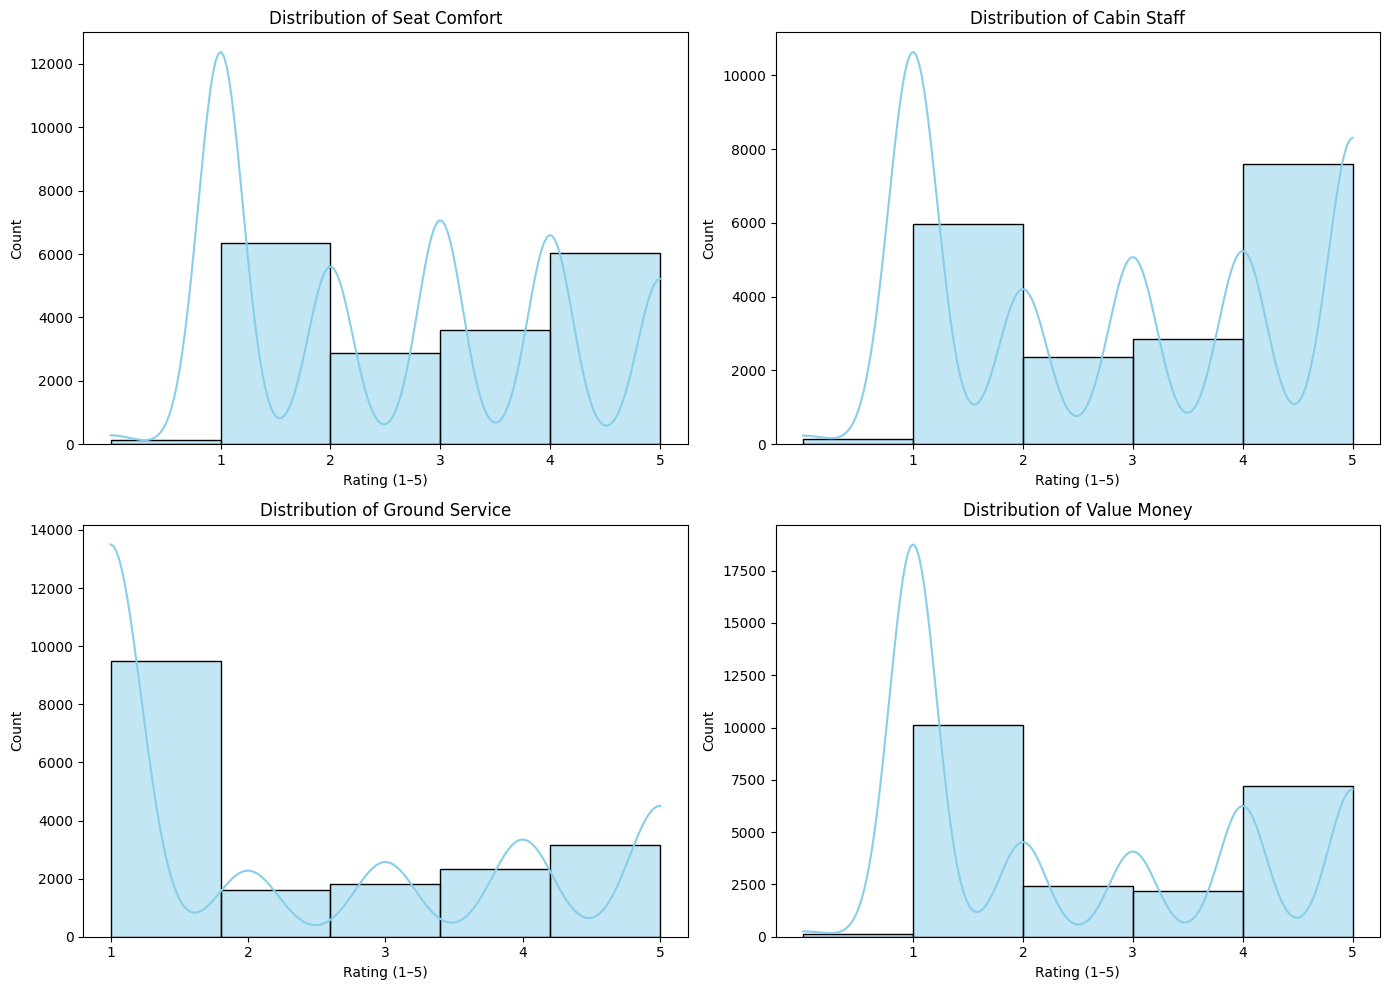

In [ ]:
# Visualize the numerical rating columns to choose method of imputation
rating_cols = ["seat_comfort", "cabin_staff", "ground_service", "value_money"]

plt.figure(figsize=(14,10))

for i, col in enumerate(rating_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], bins=5, kde=True, color='skyblue')
    plt.title(f"Distribution of {col.replace('_', ' ').title()}")
    plt.xlabel("Rating (1–5)")
    plt.ylabel("Count")
    plt.xticks([1, 2, 3, 4, 5])

plt.tight_layout()
plt.show()

We decide to use the median to fill missing numerical values because these columns are ordinal and some of them are highly skewed. The median preserves the true central tendency of the data and prevents distortion that could occur if we use the mean. This ensures cleaner EDA and more reliable modelling.

In [ ]:
# Handling missing numeric columns by filling with median
num_cols = ["seat_comfort", "cabin_staff", "ground_service", "value_money"]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col].fillna(df[col].median(), inplace=True)

In [ ]:
# Handling missing categorical columns by filling with "Unknown"
cat_cols = ["traveller_type", "seat_type", "route"]

for col in cat_cols:
    df[col].fillna("Unknown", inplace=True)

In [ ]:
# Check for any duplicate Records
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate records found: {num_duplicates}")

Number of duplicate records found: 123


In [ ]:
# Remove duplicates
df.drop_duplicates(subset="text", inplace=True)
df.reset_index(drop=True, inplace=True)

In [ ]:
# Final Cleaned Data
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23046 entries, 0 to 23045
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   airline         23046 non-null  object 
 1   rating          23046 non-null  object 
 2   text            23046 non-null  object 
 3   traveller_type  23046 non-null  object 
 4   seat_type       23046 non-null  object 
 5   route           23046 non-null  object 
 6   seat_comfort    23046 non-null  float64
 7   cabin_staff     23046 non-null  float64
 8   ground_service  23046 non-null  float64
 9   value_money     23046 non-null  float64
 10  recommended     23046 non-null  object 
dtypes: float64(4), object(7)
memory usage: 1.9+ MB


,airline,rating,text,traveller_type,seat_type,route,seat_comfort,cabin_staff,ground_service,value_money,recommended
0,AB Aviation,9,Moroni to Moheli. Turned out to be a pretty ...,Solo Leisure,Economy Class,Moroni to Moheli,4.0,5.0,4.0,3.0,yes
1,AB Aviation,1,Moroni to Anjouan. It is a very small airline...,Solo Leisure,Economy Class,Moroni to Anjouan,2.0,2.0,1.0,2.0,no
2,AB Aviation,1,Anjouan to Dzaoudzi. A very small airline an...,Solo Leisure,Economy Class,Anjouan to Dzaoudzi,2.0,1.0,1.0,2.0,no
3,Adria Airways,1,Please do a favor yourself and do not fly wi...,Solo Leisure,Economy Class,Frankfurt to Pristina,1.0,1.0,1.0,1.0,no
4,Adria Airways,1,Do not book a flight with this airline! My fr...,Couple Leisure,Economy Class,Sofia to Amsterdam via Ljubljana,1.0,1.0,1.0,1.0,no


---
## 1.5 Preprocessing

The following steps are applied to every email text:
1. **Lowercasing**: normalize case
2. **Punctuation Removal**: strip non-alphanumeric characters
3. **Tokenization** : split text into individual words
4. **Stop-Word Removal**: remove common words that carry little meaning  
5. **Lemmatization**: reduce words to their base/dictionary form  

In [ ]:
# Initialise lemmatizer and stop-word set
lemmatizer = WordNetLemmatizer()
stop_words  = set(stopwords.words('english'))

def preprocess_text(text):
    # Step 1: Lowercase
    text = text.lower()

    # Step 2: Remove punctuation and digits
    text = re.sub(r'[^\w\s]', '', text)

    # Step 3: Tokenize
    tokens = word_tokenize(text)

    # Step 4: Remove stop-words
    tokens = [t for t in tokens if t not in stop_words]

    # Step 5: Lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return ' '.join(tokens)

In [ ]:
# Apply preprocessing to all the reviews
df['clean_text'] = df['text'].apply(preprocess_text)
df[['text', 'clean_text']].head(10)

,text,clean_text
0,Moroni to Moheli. Turned out to be a pretty ...,moroni moheli turned pretty decent airline onl...
1,Moroni to Anjouan. It is a very small airline...,moroni anjouan small airline ticket advised tu...
2,Anjouan to Dzaoudzi. A very small airline an...,anjouan dzaoudzi small airline airline based c...
3,Please do a favor yourself and do not fly wi...,please favor fly adria route munich pristina j...
4,Do not book a flight with this airline! My fr...,book flight airline friend returned sofia amst...
5,Had very bad experience with rerouted and ca...,bad experience rerouted cancelled flight last ...
6,"Ljubljana to Zürich. Firstly, Ljubljana airp...",ljubljana zürich firstly ljubljana airport ter...
7,"First of all, I am not complaining about a s...",first complaining specific flight lufthansa fr...
8,Worst Airline ever! They combined two flight...,worst airline ever combined two flight save co...
9,Ljubljana to Munich. The homebase airport of ...,ljubljana munich homebase airport adria airway...


In [ ]:
# Convert into numerical features using TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,
    min_df=5,        # remove extremely rare words
    max_df=0.8       # remove overly common words
)

X_tfidf = tfidf.fit_transform(df['clean_text'])

feature_names = tfidf.get_feature_names_out()  # Save feature names

print("TF-IDF shape:", X_tfidf.shape)

TF-IDF shape: (23046, 5000)


---
# Part 2: Exploratory Data Analysis

-----
# **Univariate Analysis**

## 2.1 Overall Rating & Recommendation

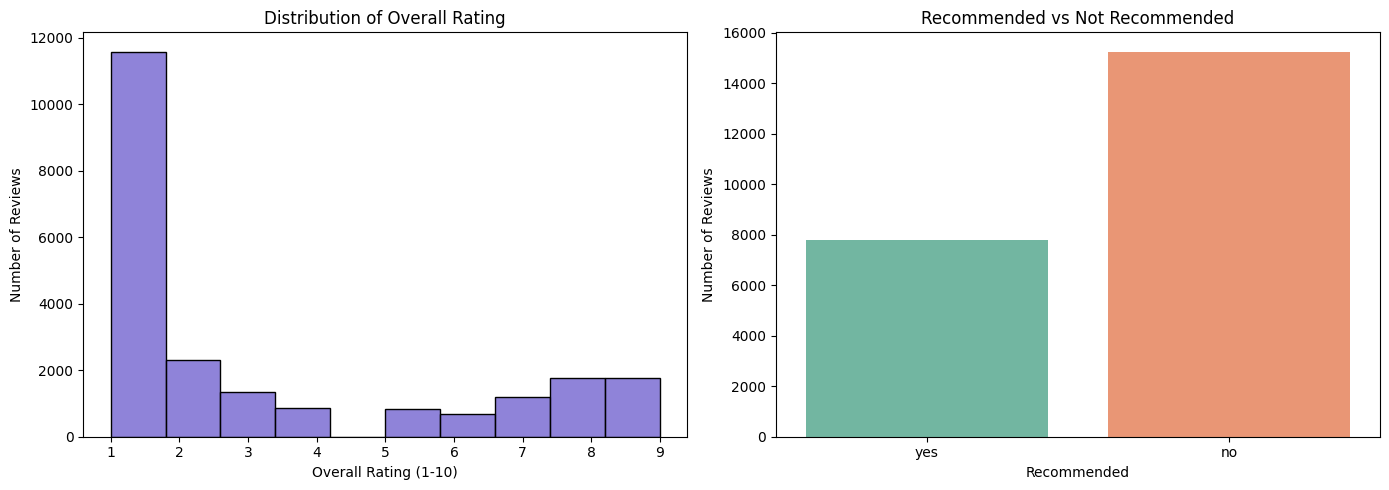

In [ ]:

rating_numeric = pd.to_numeric(df['rating'], errors='coerce')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(rating_numeric, bins=10, kde=False, color='slateblue', ax=axes[0])
axes[0].set_title("Distribution of Overall Rating")
axes[0].set_xlabel("Overall Rating (1-10)")
axes[0].set_ylabel("Number of Reviews")

sns.countplot(x='recommended', data=df, palette='Set2', ax=axes[1])
axes[1].set_title("Recommended vs Not Recommended")
axes[1].set_xlabel("Recommended")
axes[1].set_ylabel("Number of Reviews")

plt.tight_layout()
plt.show()


## 2.2 Review Volume by Airline, Traveller Type & Seat Type

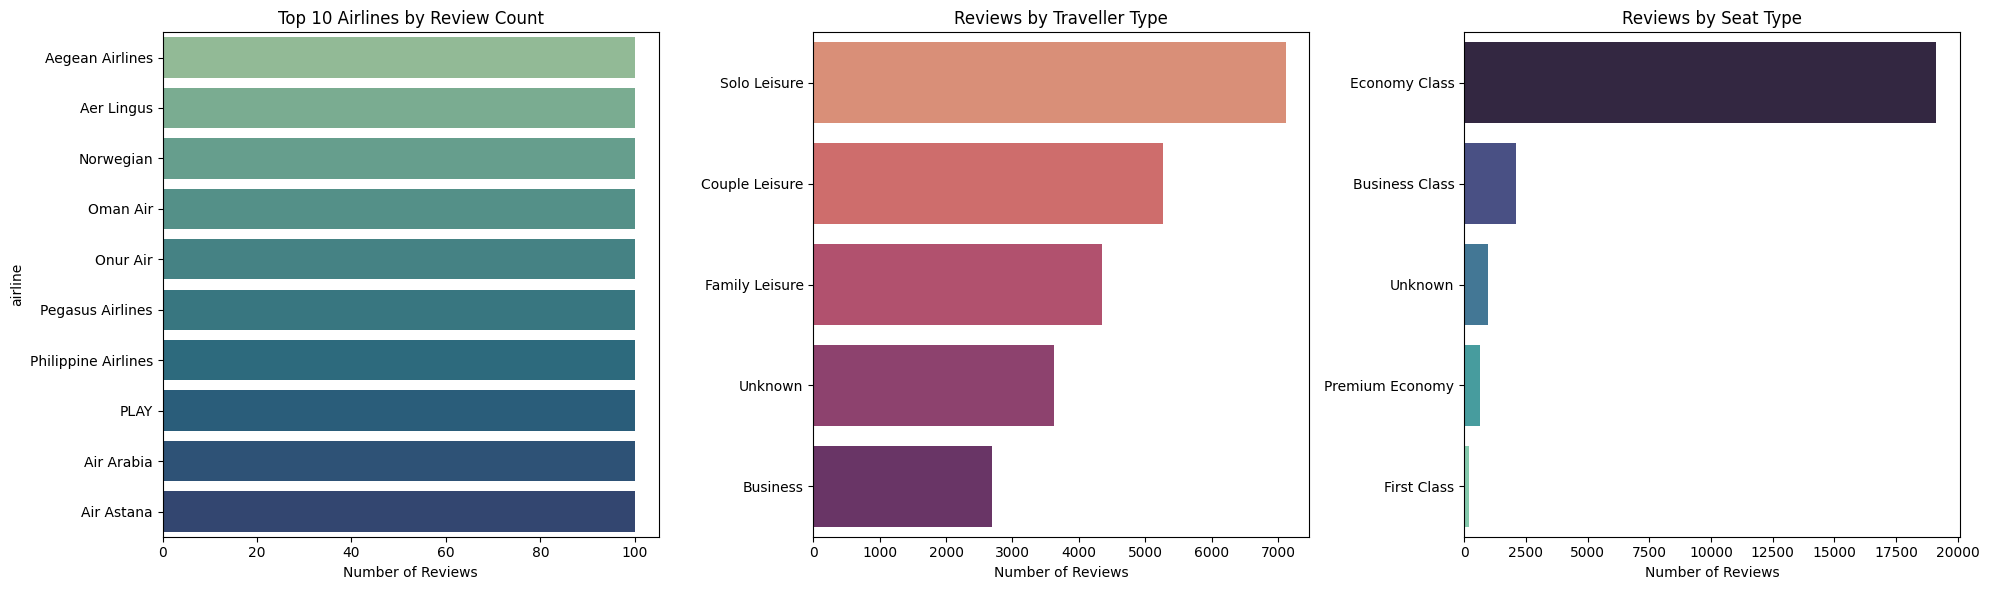

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

top_airlines = df['airline'].value_counts().head(10)
sns.barplot(x=top_airlines.values, y=top_airlines.index, palette='crest', ax=axes[0])
axes[0].set_title("Top 10 Airlines by Review Count")
axes[0].set_xlabel("Number of Reviews")

sns.countplot(y='traveller_type', data=df, order=df['traveller_type'].value_counts().index,
              palette='flare', ax=axes[1])
axes[1].set_title("Reviews by Traveller Type")
axes[1].set_xlabel("Number of Reviews")
axes[1].set_ylabel("")

sns.countplot(y='seat_type', data=df, order=df['seat_type'].value_counts().index,
              palette='mako', ax=axes[2])
axes[2].set_title("Reviews by Seat Type")
axes[2].set_xlabel("Number of Reviews")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()


# **Bivariate Analysis**

## 2.3 Review Length Analysis

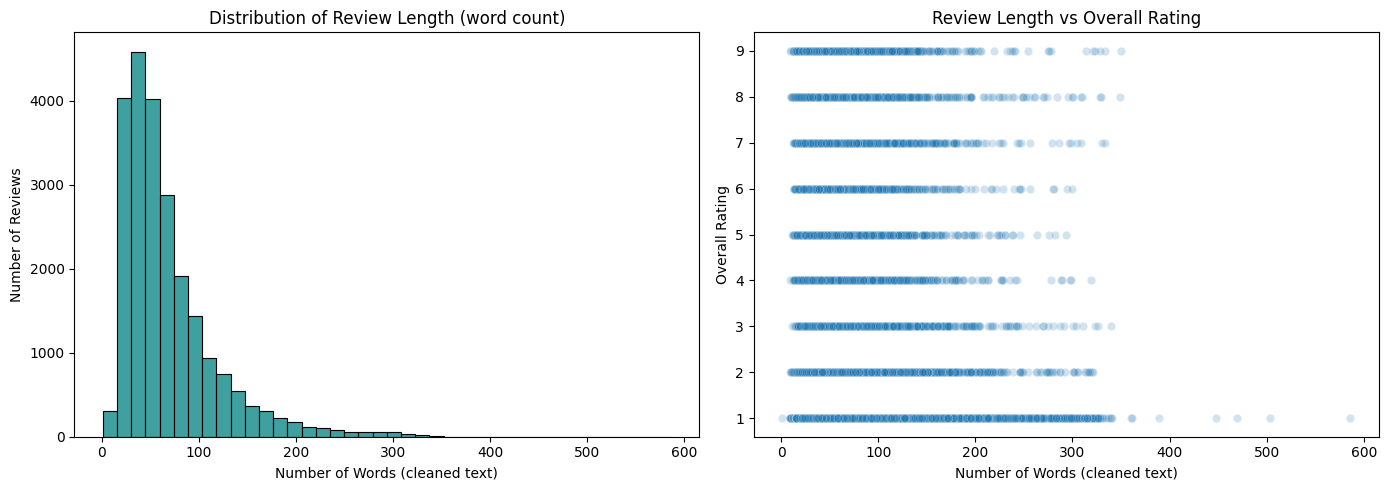

count    23046.000000
mean        68.170615
std         49.859089
min          1.000000
25%         35.000000
50%         54.000000
75%         85.000000
max        586.000000
Name: clean_text, dtype: float64


In [ ]:
# Word count per (cleaned) review
review_word_count = df['clean_text'].str.split().apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(review_word_count, bins=40, color='teal', ax=axes[0])
axes[0].set_title("Distribution of Review Length (word count)")
axes[0].set_xlabel("Number of Words (cleaned text)")
axes[0].set_ylabel("Number of Reviews")

sns.scatterplot(x=review_word_count, y=rating_numeric, alpha=0.2, ax=axes[1])
axes[1].set_title("Review Length vs Overall Rating")
axes[1].set_xlabel("Number of Words (cleaned text)")
axes[1].set_ylabel("Overall Rating")

plt.tight_layout()
plt.show()

print(review_word_count.describe())


# **Multivariate Analysis**

## 2.4 Correlation Between Rating Dimensions

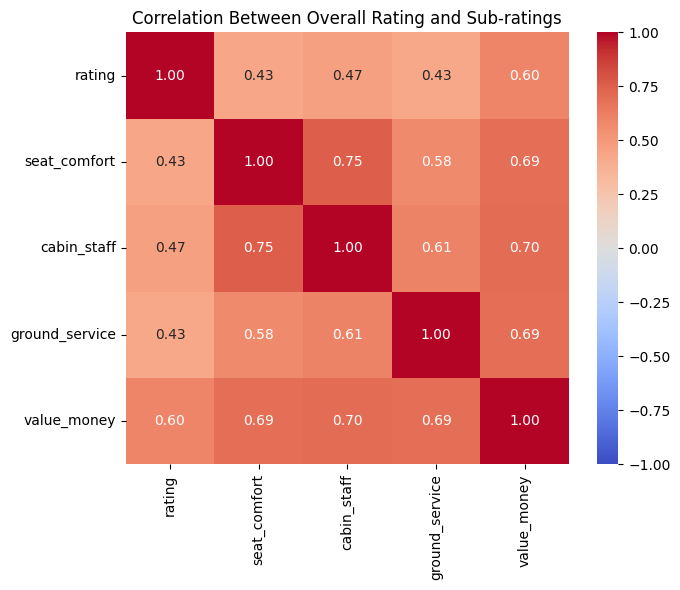

In [ ]:
rating_dims_df = pd.DataFrame({
    'rating': rating_numeric,
    'seat_comfort': pd.to_numeric(df['seat_comfort'], errors='coerce'),
    'cabin_staff': pd.to_numeric(df['cabin_staff'], errors='coerce'),
    'ground_service': pd.to_numeric(df['ground_service'], errors='coerce'),
    'value_money': pd.to_numeric(df['value_money'], errors='coerce'),
})

plt.figure(figsize=(7, 6))
sns.heatmap(rating_dims_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Between Overall Rating and Sub-ratings")
plt.tight_layout()
plt.show()


## 2.5 Overall Vocabulary Preview

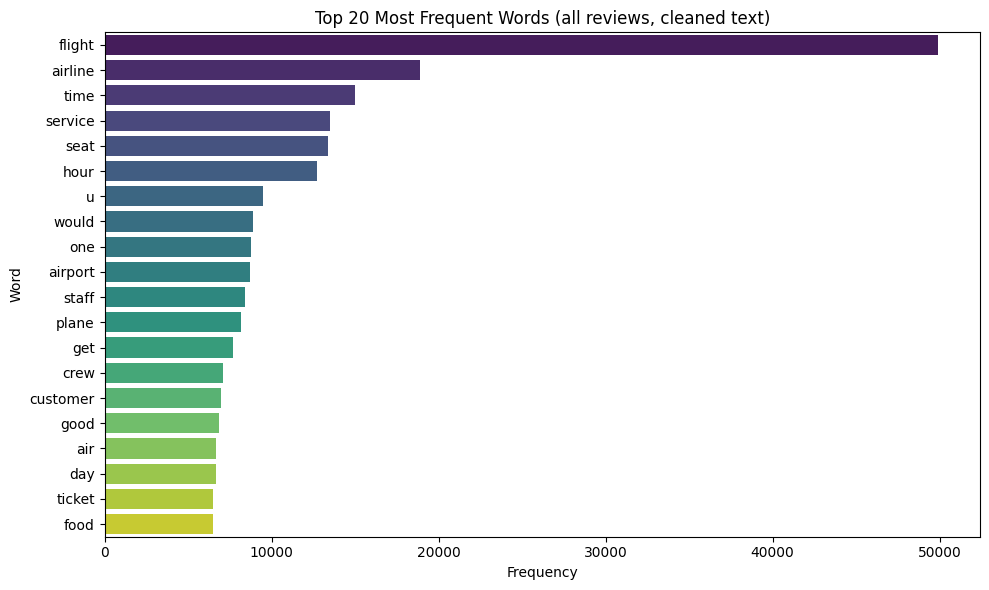

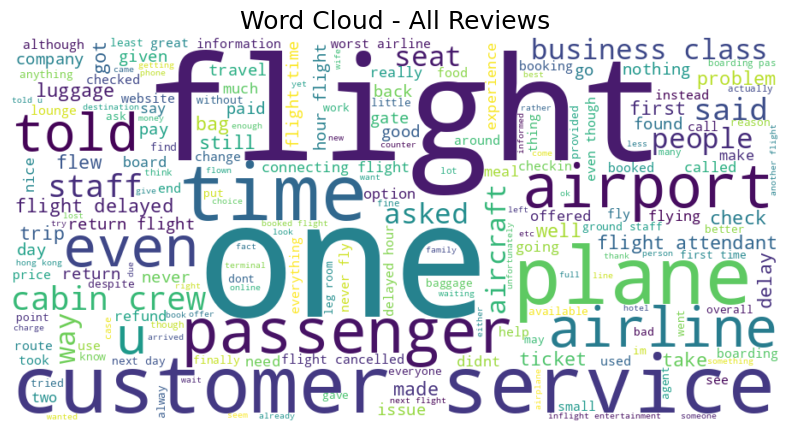

In [ ]:

all_words = ' '.join(df['clean_text']).split()
word_freq = Counter(all_words).most_common(20)
words, counts = zip(*word_freq)

plt.figure(figsize=(10, 6))
sns.barplot(x=list(counts), y=list(words), palette='viridis')
plt.title("Top 20 Most Frequent Words (all reviews, cleaned text)")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.show()

wc_all = WordCloud(background_color='white', width=900, height=450).generate(' '.join(df['clean_text']))
plt.figure(figsize=(10, 5))
plt.imshow(wc_all, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud - All Reviews", fontsize=18)
plt.show()


# Part 3: Topic Modelling

-----
## 3.1 LDA Model

In [ ]:
# Train the model
num_topics = 5

lda = LatentDirichletAllocation(
    n_components=num_topics,
    random_state=42,
    learning_method='batch'
)

lda.fit(X_tfidf)

LatentDirichletAllocation(n_components=5, random_state=42)

In [ ]:
# Extract top words per topic
def display_topics(model, feature_names, num_words=15):
    for idx, topic in enumerate(model.components_):
        print(f"\nTopic #{idx+1}:")
        top_words = [feature_names[i] for i in topic.argsort()[-num_words:]]
        print(", ".join(top_words))

feature_names = tfidf.get_feature_names_out()
display_topics(lda, feature_names)


Topic #1:
drink, served, comfortable, friendly, time, business, meal, class, cabin, service, crew, food, seat, good, flight

Topic #2:
get, told, seat, one, gate, staff, airport, passenger, delay, airline, time, delayed, plane, hour, flight

Topic #3:
clean, drink, food, aircraft, staff, plane, service, friendly, cabin, airline, time, crew, good, seat, flight

Topic #4:
south, africa, staff, kigali, kg, nairobi, durban, weight, carry, luggage, baby, bag, town, cape, johannesburg

Topic #5:
airport, luggage, never, get, email, hour, time, cancelled, service, day, refund, ticket, customer, airline, flight


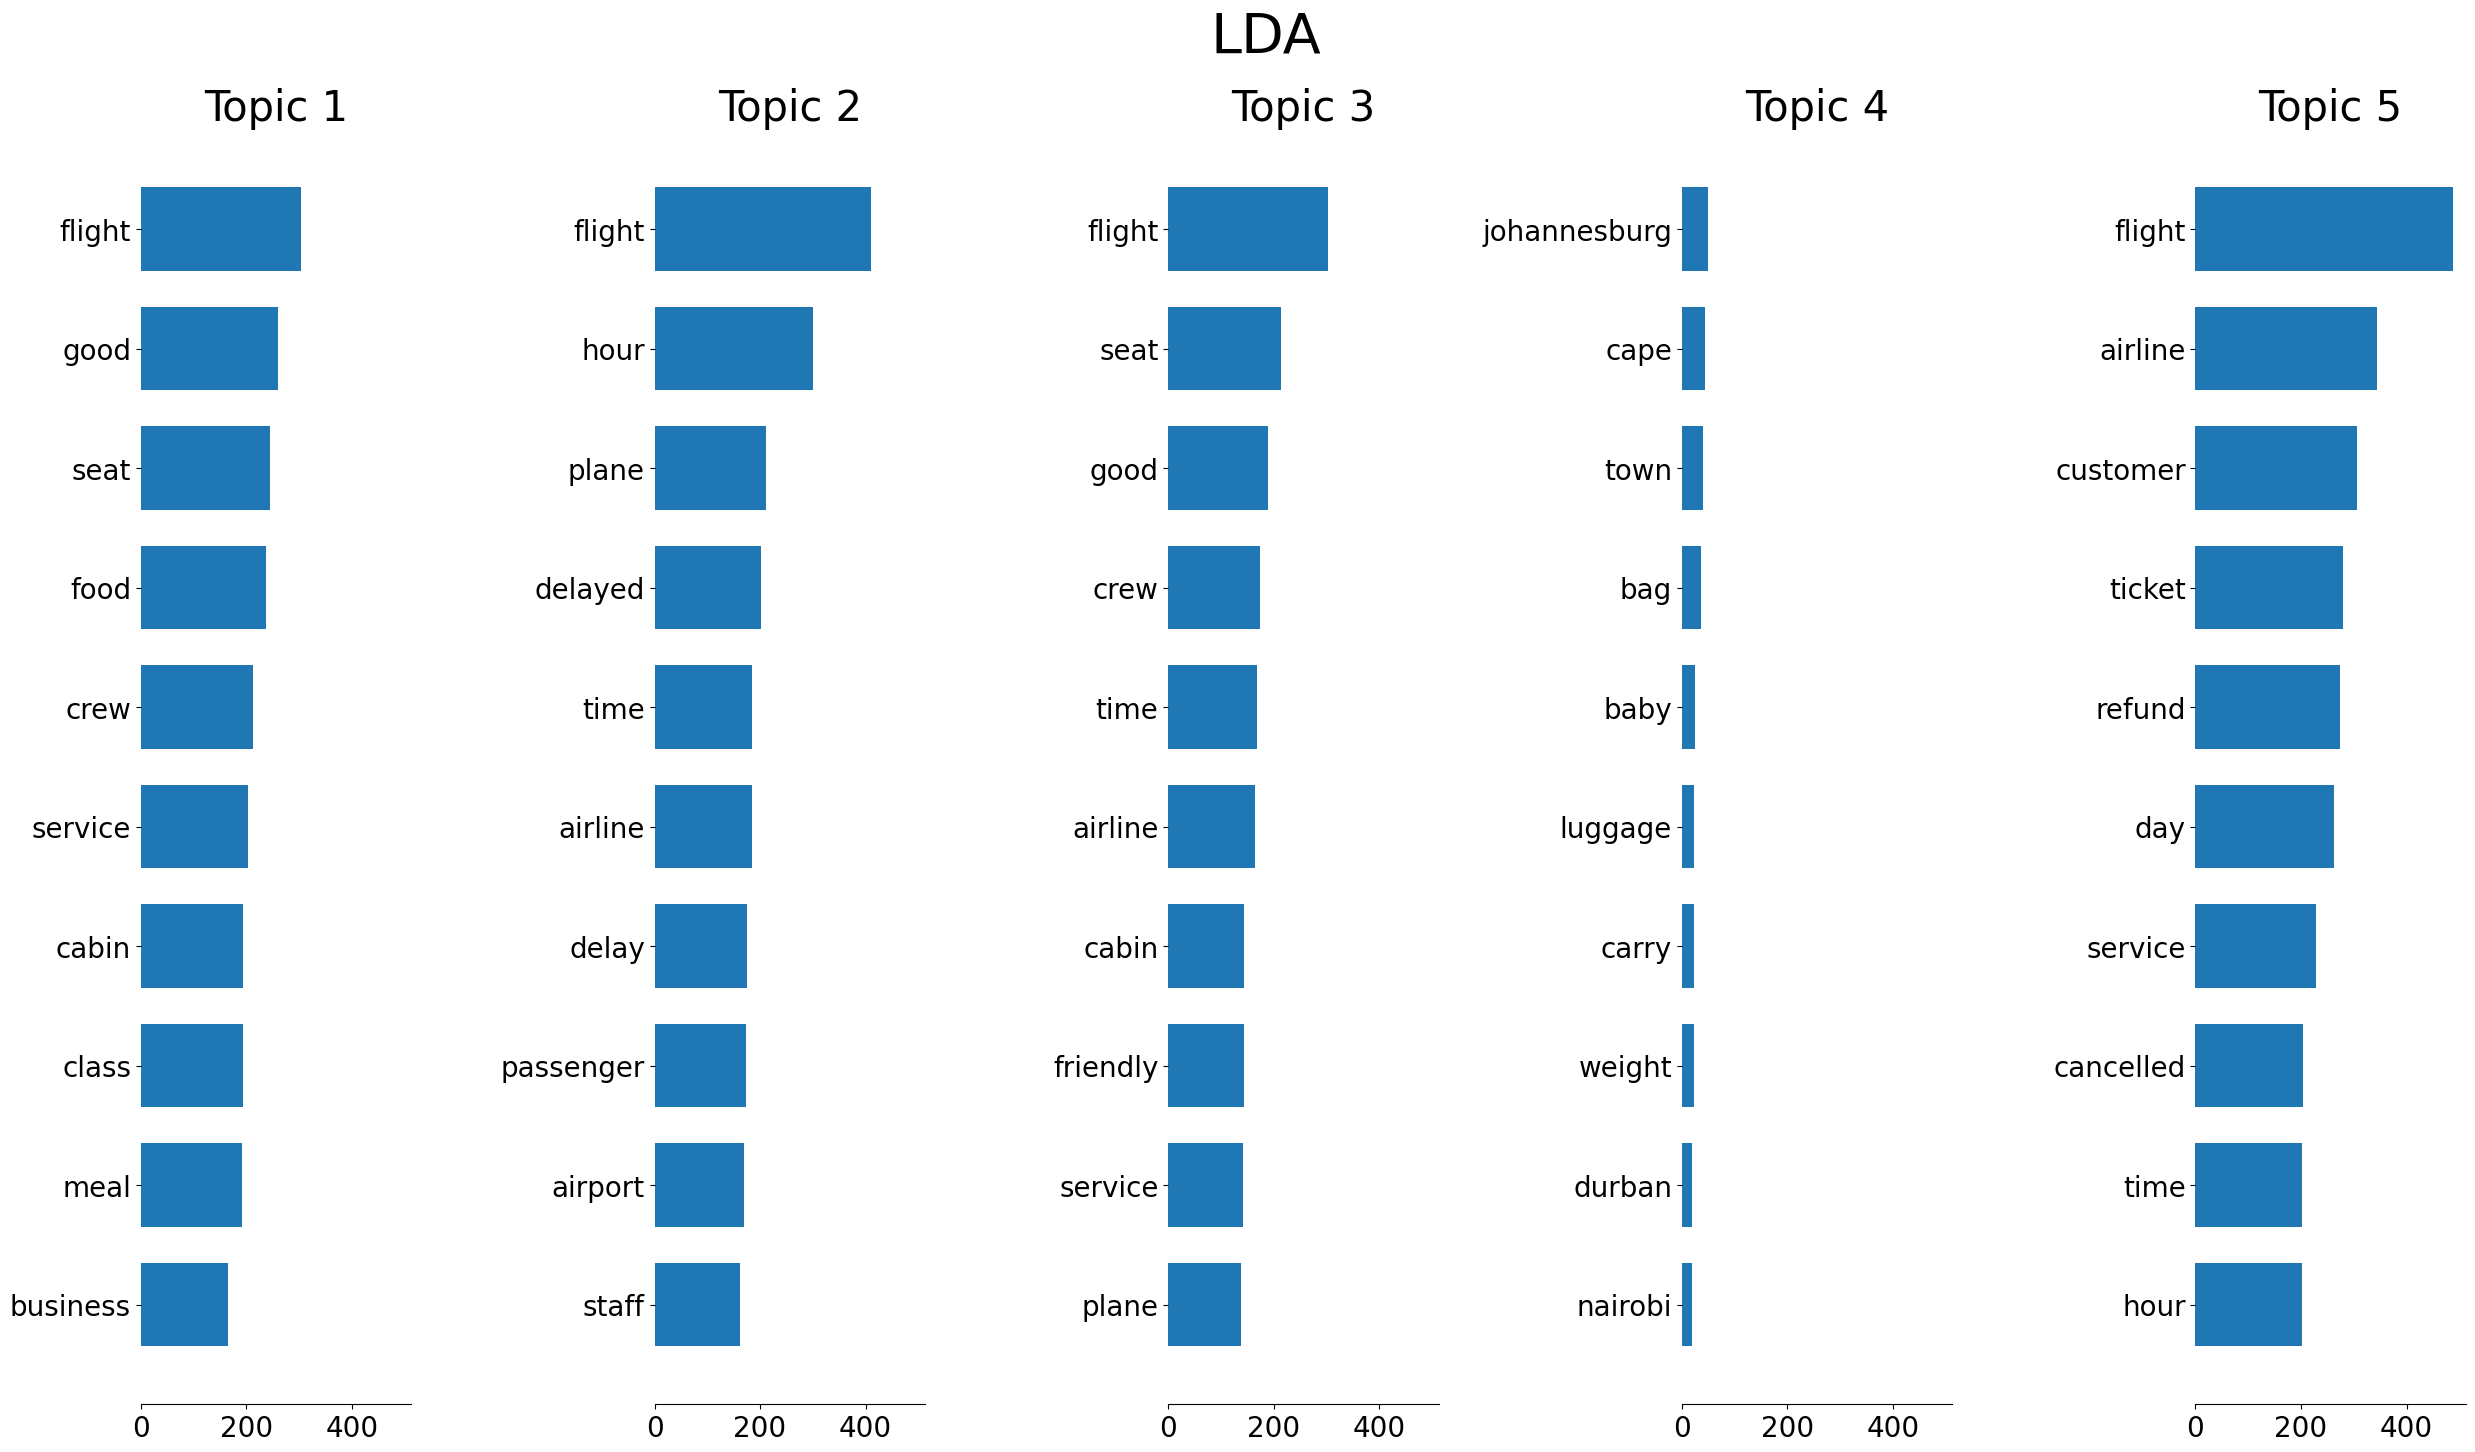

In [ ]:
# Bar-chart view of top words per topic (same style used below for NMF)
def plot_top_words(model, feature_names, n_top_words=10, title="LDA"):
    fig, axes = plt.subplots(1, num_topics, figsize=(30, 15), sharex=True)
    axes = axes.flatten()
    for topic_idx, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[: -n_top_words - 1 : -1]
        top_features = [feature_names[i] for i in top_features_ind]
        weights = topic[top_features_ind]

        ax = axes[topic_idx]
        ax.barh(top_features, weights, height=0.7)
        ax.set_title(f"Topic {topic_idx + 1}", fontdict={"fontsize": 30})
        ax.invert_yaxis()
        ax.tick_params(axis="both", which="major", labelsize=20)
        for spine in "top right left".split():
            ax.spines[spine].set_visible(False)
        fig.suptitle(title, fontsize=40)

    plt.subplots_adjust(top=0.90, bottom=0.05, wspace=0.90, hspace=0.3)
    plt.show()

plot_top_words(lda, feature_names, title="LDA")


In [ ]:
# Assign Dominant Topic to each review
topic_values = lda.transform(X_tfidf)
df['dominant_topic'] = topic_values.argmax(axis=1)

df[['clean_text', 'dominant_topic']].head()

,clean_text,dominant_topic
0,moroni moheli turned pretty decent airline onl...,2
1,moroni anjouan small airline ticket advised tu...,1
2,anjouan dzaoudzi small airline airline based c...,2
3,please favor fly adria route munich pristina j...,4
4,book flight airline friend returned sofia amst...,4


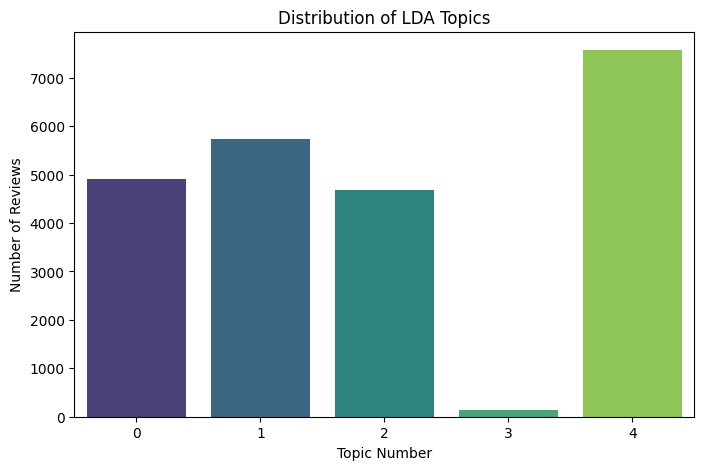

In [ ]:
# Topic Distribution Chart
plt.figure(figsize=(8,5))
sns.countplot(x=df['dominant_topic'], palette='viridis')
plt.title("Distribution of LDA Topics")
plt.xlabel("Topic Number")
plt.ylabel("Number of Reviews")
plt.show()

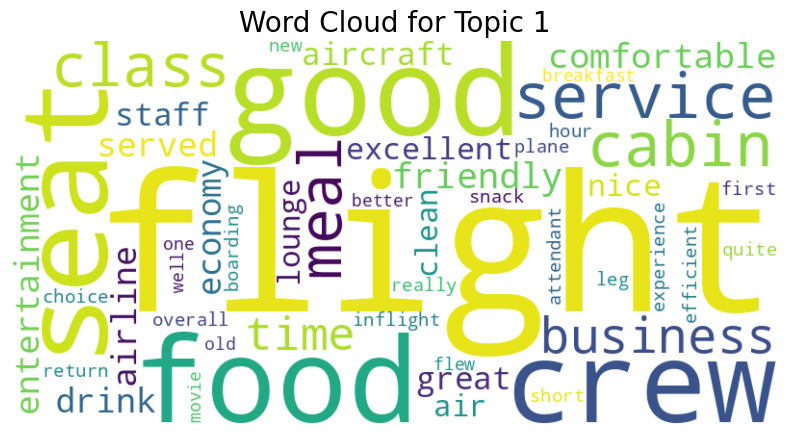

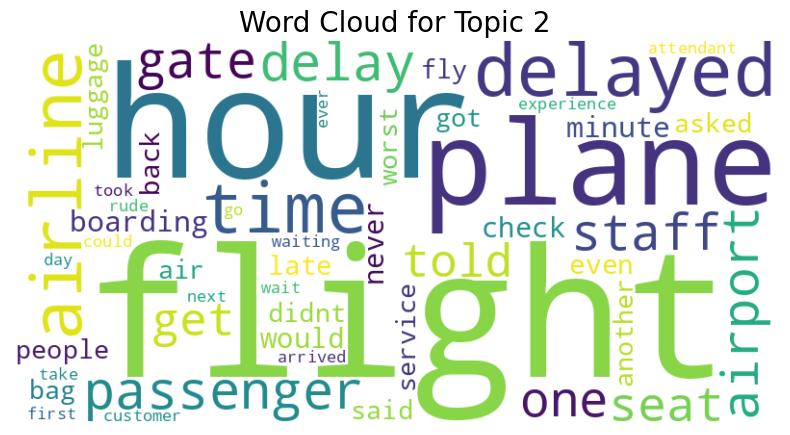

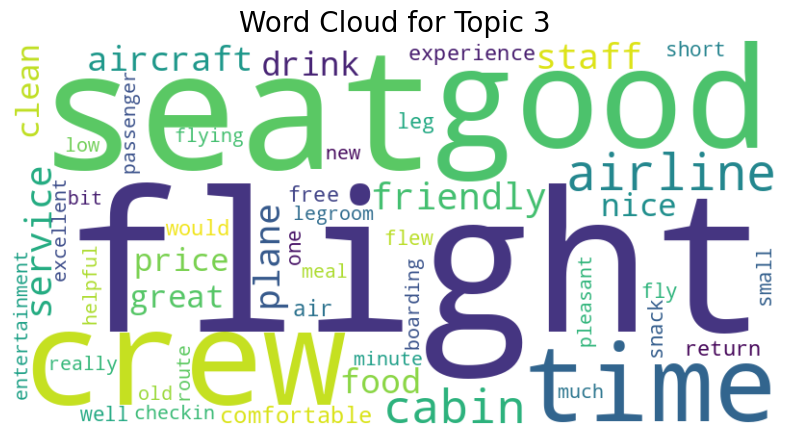

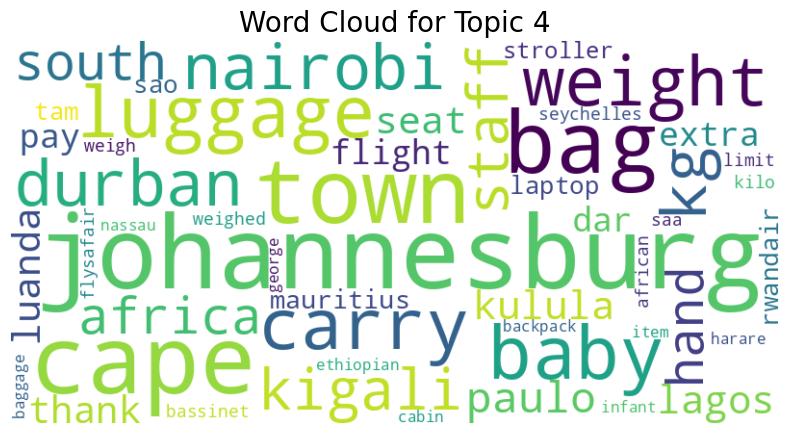

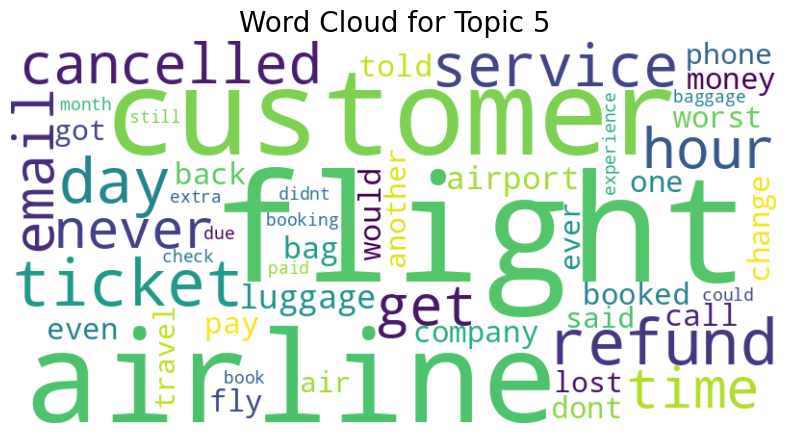

In [ ]:
# Create a word cloud to identify top 50 words appearing in each topics
def plot_wordcloud(model, feature_names, topic_idx):
    topic = model.components_[topic_idx]
    top_indices = topic.argsort()[-50:]  # top 50 words
    top_words = {feature_names[i]: topic[i] for i in top_indices}

    wc = WordCloud(
        background_color='white',
        width=800,
        height=400
    ).generate_from_frequencies(top_words)

    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Word Cloud for Topic {topic_idx+1}", fontsize=20)
    plt.show()

# Generate word clouds for all topics
for i in range(num_topics):
    plot_wordcloud(lda, feature_names, i)

### LDA Topics Interpretation

**Topic 1 — Business Class Experience & Onboard Meal Service**

Top words:  
drink, served, comfortable, friendly, time, business, meal, class, cabin, service, crew, food, seat, good, flight

Interpretation:
This topic reflects premium cabin experience, including business‑class seating, meal service, drinks, and overall comfort. Passengers frequently mention friendly crew interactions, food quality, and cabin comfort.

-----
**Topic 2 — Gate Issues, Delays & Staff Communication Problems**

Top words:  
get, told, seat, one, gate, staff, airport, passenger, delay, airline, time, delayed, plane, hour, flight

Interpretation:
This topic captures gate‑related issues, miscommunication from staff, seating problems, and delays. Passengers mention being “told” conflicting information, long waits, and poor coordination at the airport.

-----
**Topic 3 — Cabin Cleanliness & General Service Quality**

Top words:  
clean, drink, food, aircraft, staff, plane, service, friendly, cabin, airline, time, crew, good, seat, flight

Interpretation:
This topic reflects general cabin experience, including cleanliness, food/drink service, staff friendliness, and aircraft condition. It represents broad satisfaction with the onboard environment.

-----
**Topic 4 — Africa Route Travel & Baggage Weight Issues**

Top words:  
south, africa, staff, kigali, kg, nairobi, durban, weight, carry, luggage, baby, bag, town, cape, johannesburg

Interpretation:
This topic is highly route‑specific, focusing on African destinations (South Africa, Nairobi, Kigali, Durban). It also highlights baggage weight issues, carry‑on restrictions, and luggage handling concerns.

----
**Topic 5 — Refund Problems, Cancellations & Customer Service Failures**

Top words:  
airport, luggage, never, get, email, hour, time, cancelled, service, day, refund, ticket, customer, airline, flight

Interpretation:
This topic reflects negative customer service experiences, especially around refunds, cancellations, unresolved issues, and lack of follow‑up (email, ticket problems). Passengers express frustration with poor communication and long wait times.

---
## 3.2 NMF Model

In [ ]:
# Train the NMF model on the same TF-IDF features used for LDA

nmf = NMF(
    n_components=num_topics,
    beta_loss="kullback-leibler",
    solver='mu',
    random_state=42
)

nmf.fit(X_tfidf)


NMF(beta_loss='kullback-leibler', n_components=5, random_state=42, solver='mu')

In [ ]:
# Extract top words per topic (reusing the function defined for LDA)
display_topics(nmf, feature_names)



Topic #1:
get, next, hotel, fly, never, customer, airport, cancelled, delay, time, delayed, day, airline, hour, flight

Topic #2:
drink, clean, airline, nice, aircraft, great, comfortable, time, food, cabin, friendly, service, crew, flight, good

Topic #3:
phone, never, dont, paid, extra, company, call, email, money, service, pay, airline, customer, refund, ticket

Topic #4:
hour, counter, flight, passenger, arrived, baggage, staff, plane, airport, minute, gate, check, boarding, luggage, bag

Topic #5:
leg, one, passenger, attendant, premium, meal, water, plane, economy, row, business, flight, food, class, seat


In [ ]:
# Bar-chart view of top words per topic (same visualization style used in class for NMF)
def plot_top_words(model, feature_names, n_top_words=10):
    fig, axes = plt.subplots(1, num_topics, figsize=(30, 15), sharex=True)
    axes = axes.flatten()
    for topic_idx, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[: -n_top_words - 1 : -1]
        top_features = [feature_names[i] for i in top_features_ind]
        weights = topic[top_features_ind]

        ax = axes[topic_idx]
        ax.barh(top_features, weights, height=0.7)
        ax.set_title(f"Topic {topic_idx + 1}", fontdict={"fontsize": 30})
        ax.invert_yaxis()
        ax.tick_params(axis="both", which="major", labelsize=20)
        for spine in "top right left".split():
            ax.spines[spine].set_visible(False)
        fig.suptitle('NMF', fontsize=40)

    plt.subplots_adjust(top=0.90, bottom=0.05, wspace=0.90, hspace=0.3)
    plt.show()


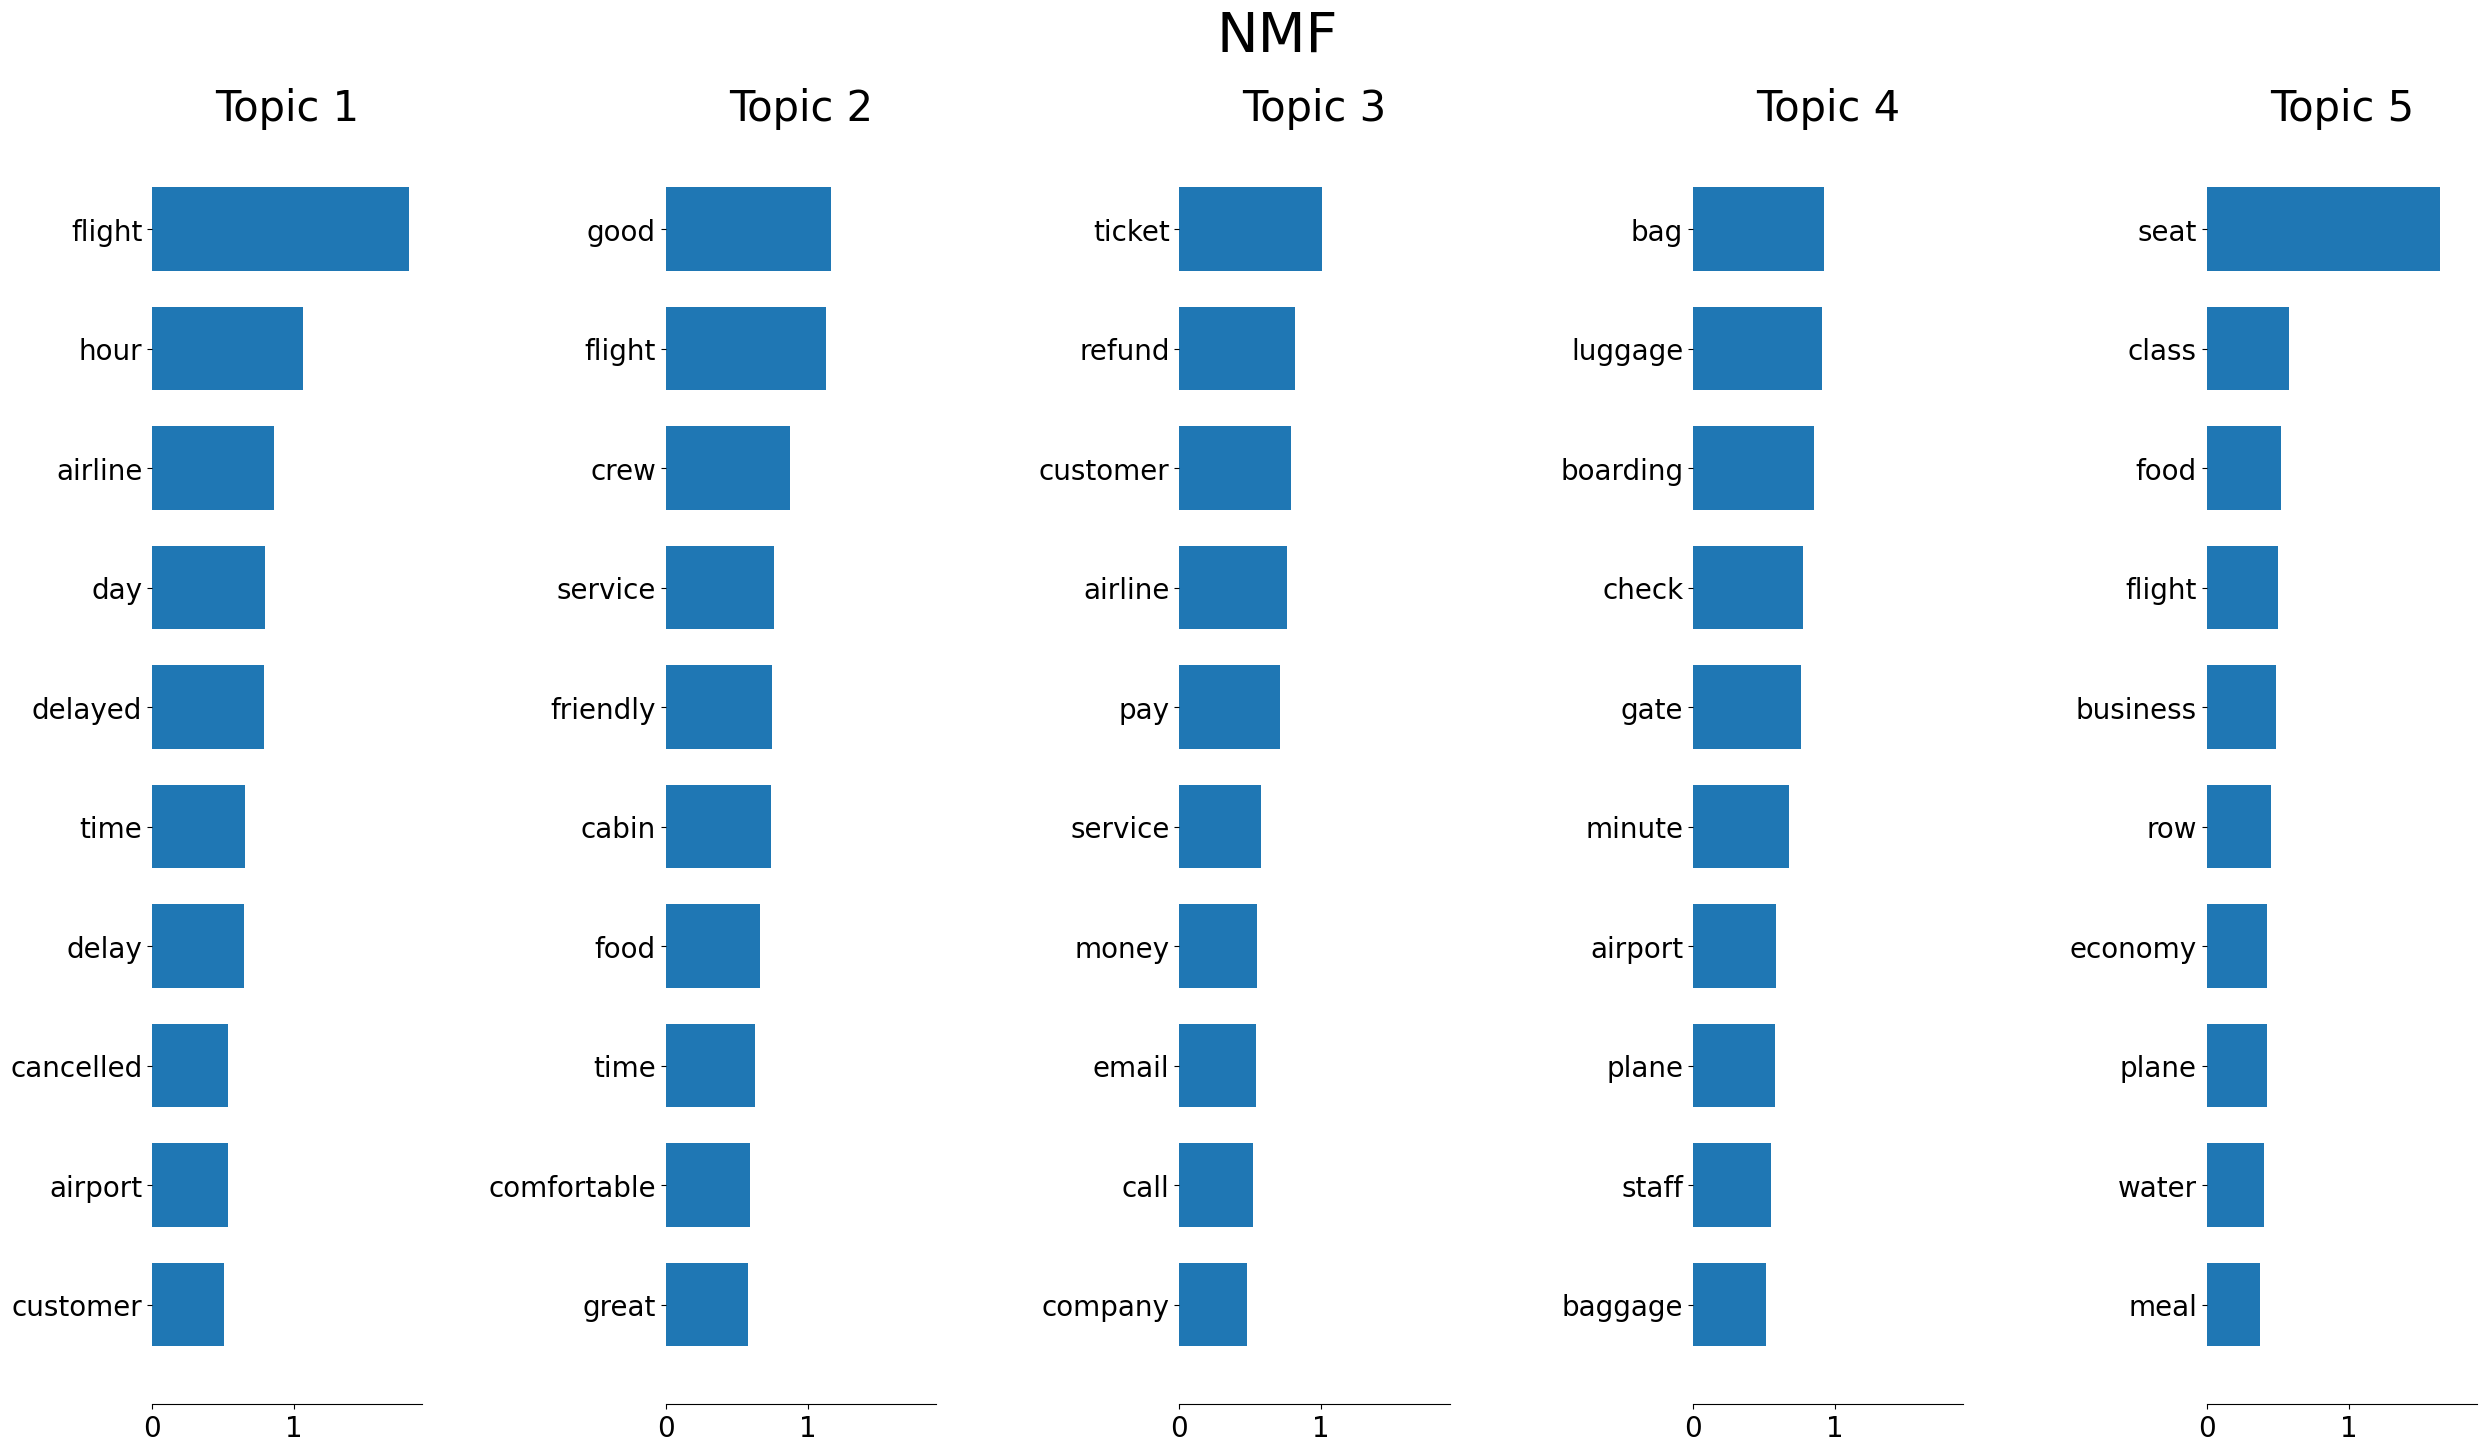

In [ ]:
# Apply the function
plot_top_words(nmf, feature_names)


In [ ]:
# Assign Dominant Topic to each review (NMF)
nmf_topic_values = nmf.transform(X_tfidf)
df['nmf_dominant_topic'] = nmf_topic_values.argmax(axis=1)

df[['clean_text', 'nmf_dominant_topic']].head()


,clean_text,nmf_dominant_topic
0,moroni moheli turned pretty decent airline onl...,1
1,moroni anjouan small airline ticket advised tu...,3
2,anjouan dzaoudzi small airline airline based c...,1
3,please favor fly adria route munich pristina j...,0
4,book flight airline friend returned sofia amst...,0


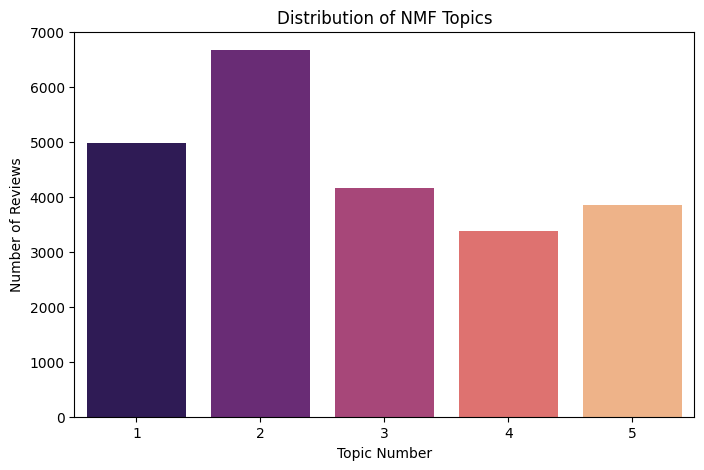

In [ ]:
# Topic Distribution Chart (NMF)
plt.figure(figsize=(8,5))
sns.countplot(x=df['nmf_dominant_topic'] + 1, palette='magma')
plt.title("Distribution of NMF Topics")
plt.xlabel("Topic Number")
plt.ylabel("Number of Reviews")
plt.show()


In [ ]:
# Average customer rating by topic (NMF)
rating_numeric_nmf = pd.to_numeric(df['rating'], errors='coerce')
nmf_topic_rating = pd.DataFrame({'rating': rating_numeric_nmf, 'nmf_dominant_topic': df['nmf_dominant_topic']}).groupby('nmf_dominant_topic')['rating'].mean()
nmf_topic_share = df['nmf_dominant_topic'].value_counts(normalize=True).sort_index() * 100
nmf_summary = pd.DataFrame({'Avg Rating': nmf_topic_rating.sort_index(), 'Share of Reviews (%)': nmf_topic_share.round(1)})
nmf_summary.index = nmf_summary.index + 1
nmf_summary.index.name = 'Topic'
nmf_summary

,Avg Rating,Share of Reviews (%)
Topic,,
1,1.625026,21.6
2,5.550928,29.0
3,1.522612,18.1
4,2.720282,14.6
5,3.125101,16.7


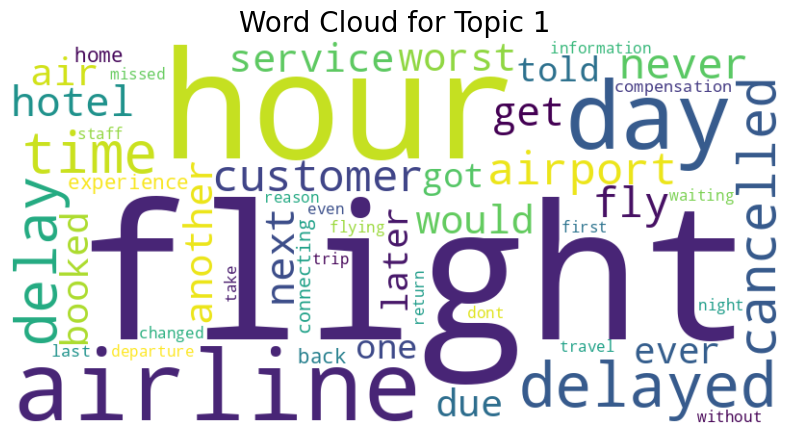

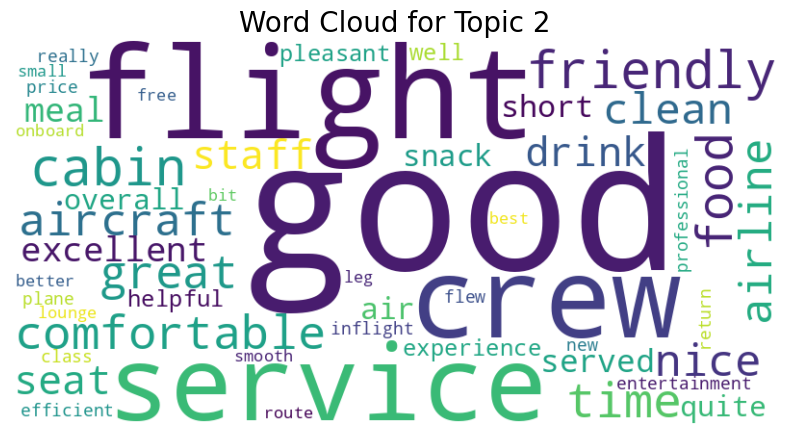

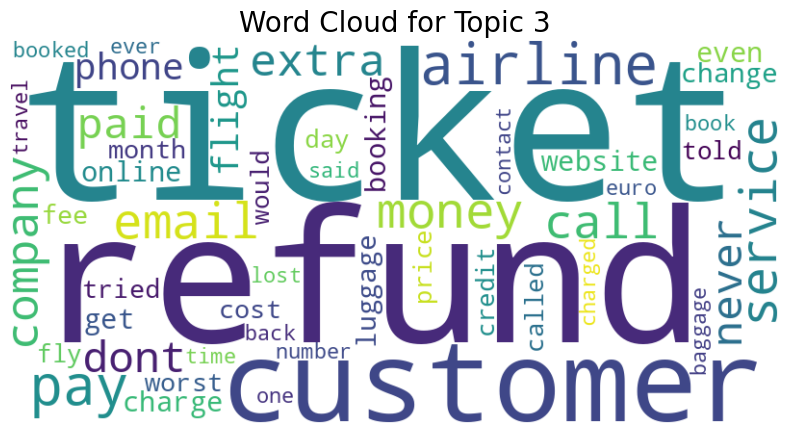

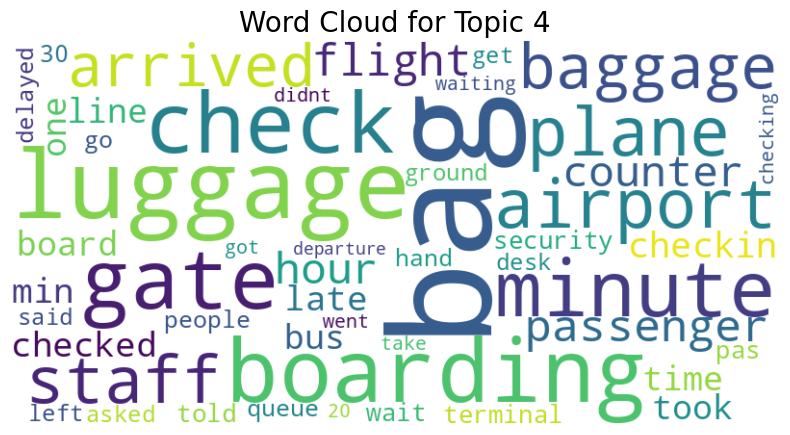

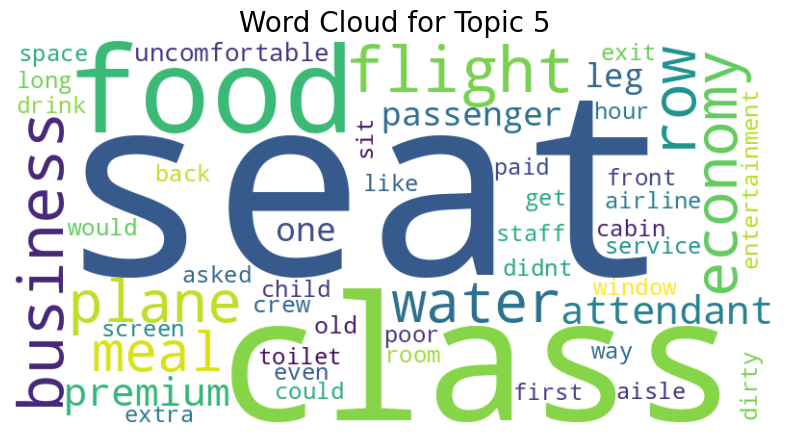

In [ ]:
# Word clouds for each NMF topic (reusing the function defined for LDA)
for i in range(num_topics):
    plot_wordcloud(nmf, feature_names, i)


### NMF Topics Interpretation


**Topic 1: Flighe Delays, Cancellations & Schedule Disruption**

Top words:
get, next, hotel, fly, never, customer, airport, cancelled, delay, time, delayed, day, airline, hour, flight

Interpretation:
This topic captures review patterns related to flight cancellations, severe delays, and the resulting customer care logstics such as overnight hotel stays or long waiting hours at the airport.

-----
**Topic 2: Positive Cabin Experience**

Top words:
drink, clean, airline, nice, aircraft, great, comfortable, time, food, cabin, friendly, service, crew, flight, good

Interpretation:
This topic reflects overall positive passenger experiences, highlighting friendly cabin staff, clean aircraft interiors, comfortable seating, and satisfactory food and beverage services.

-----
**Topic 3: Fees & Customer Support Escalations**

Top words:
phone, never, dont, paid, extra, company, call, email, money, service, pay, airline, customer, refund, ticket

Interpretation:
This topic centers around financial disputes, payment issues for extra services, difficult refund processes, and unresolved complaints when interacting with airline customer support via phone or email.

-----
**Topic 4 Airport Boarding & Baggage Handling Issues**

Top words:
hour, counter, flight, passenger, arrived, baggage, staff, plane, airport, minute, gate, check, boarding, luggage, bag

Interpretation:
This topic captures operational friction at the airport ground level, specifically focusing on check-in counters, gate boarding procedures, long queues, and baggage/luggage handling concerns.

-----
**Topic 5: Seat Comfort & Cabin Class Features**

Top words:
leg, one, passenger, attendant, premium, meal, water, plane, economy, row, business, flight, food, class, seat

Interpretation:
This topic highlights physical seating aspects and cabin class distinctions (such as Business Class, Premium Economy, and Economy), including legroom space, row arrangements, and flight attendant meal service.


---
# Part 4: Model Evaluation & Comparision

-----
## 4.1.1 Quantitative Evaluation

We evaluate LDA and NMF on complementary criteria:
- **Coherence Score (C_v)**: how semantically related the top words within each topic are (higher is better).
- **Topic Diversity**: the proportion of unique words across all topics' top words (higher = less redundant/overlapping topics).


In [ ]:
# Tokenized texts (already cleaned/lemmatized) required by gensim's coherence pipeline
tokenized_texts = [t.split() for t in df['clean_text']]
dictionary = Dictionary(tokenized_texts)

def get_topic_words(model, feature_names, num_words=15):
    return [[feature_names[i] for i in topic.argsort()[-num_words:]] for topic in model.components_]

lda_topic_words = get_topic_words(lda, feature_names)
nmf_topic_words = get_topic_words(nmf, feature_names)

lda_coherence = CoherenceModel(
    topics=lda_topic_words, texts=tokenized_texts, dictionary=dictionary, coherence='c_v'
).get_coherence()

nmf_coherence = CoherenceModel(
    topics=nmf_topic_words, texts=tokenized_texts, dictionary=dictionary, coherence='c_v'
).get_coherence()

print(f"LDA Coherence Score (C_v): {lda_coherence:.4f}")
print(f"NMF Coherence Score (C_v): {nmf_coherence:.4f}")


LDA Coherence Score (C_v): 0.4609
NMF Coherence Score (C_v): 0.5090


In [ ]:
# Topic Diversity: proportion of unique words among all topics' top words
def topic_diversity(topic_words):
    unique_words = set(w for topic in topic_words for w in topic)
    total_words = sum(len(topic) for topic in topic_words)
    return len(unique_words) / total_words

lda_diversity = topic_diversity(lda_topic_words)
nmf_diversity = topic_diversity(nmf_topic_words)

print(f"LDA Topic Diversity: {lda_diversity:.4f}")
print(f"NMF Topic Diversity: {nmf_diversity:.4f}")


LDA Topic Diversity: 0.6667
NMF Topic Diversity: 0.8133


In [ ]:
# Side-by-side comparison table
comparison_df = pd.DataFrame({
    'Metric': [
        'Coherence Score (C_v): higher is better',
        'Topic Diversity: higher is better',
    ],
    'LDA': [f"{lda_coherence:.4f}", f"{lda_diversity:.4f}"],
    'NMF': [f"{nmf_coherence:.4f}", f"{nmf_diversity:.4f}"]
})
comparison_df


,Metric,LDA,NMF
0,Coherence Score (C_v): higher is better,0.4609,0.5090
1,Topic Diversity: higher is better,0.6667,0.8133


### 4.1.2 Qualitative Stress-Test: Custom Reviews

As a more intuitive check, we wrote a few reviews and see whether each model routes them to different topics with a confident margin.

In [ ]:
# Hand-written reviews, each intentionally aligned with one distinct theme
test_reviews = [
    ("Flight delayed for six hours, no communication from staff and no refund offered.", "Delays / disruption"),
    ("Extra baggage fees were confusing at check-in, and the queue took forever.", "Baggage / check-in"),
    ("The cabin was spotless and the crew was incredibly friendly and helpful throughout.", "Cabin experience"),
    ("Business class seat was comfortable and the in-flight meal was excellent.", "Business class / meal"),
    ("We requested a refund after the flight was cancelled but customer service never responded.", "Refund / service failure"),
]

def top_words_for_topic(model, feature_names, topic_idx, n=6):
    topic = model.components_[topic_idx]
    top_idx = topic.argsort()[-n:][::-1]
    return ", ".join(feature_names[i] for i in top_idx)

rows = []
for text, intended_theme in test_reviews:
    clean = preprocess_text(text)
    vec = tfidf.transform([clean])

    lda_dist = lda.transform(vec)[0]
    lda_topic = lda_dist.argmax()
    lda_sorted = sorted(lda_dist, reverse=True)
    lda_gap = lda_sorted[0] - lda_sorted[1]

    nmf_dist = nmf.transform(vec)[0]
    nmf_topic = nmf_dist.argmax()
    nmf_sorted = sorted(nmf_dist, reverse=True)
    nmf_share = nmf_sorted[0] / (nmf_sorted[0] + nmf_sorted[1] + 1e-9)

    rows.append({
        "Review (intended theme)": intended_theme,
        "LDA topic": lda_topic + 1,
        "LDA top words": top_words_for_topic(lda, feature_names, lda_topic),
        "LDA confidence gap": round(lda_gap, 3),
        "NMF topic": nmf_topic + 1,
        "NMF top words": top_words_for_topic(nmf, feature_names, nmf_topic),
        "NMF top-share": round(nmf_share, 3),
    })

injection_df = pd.DataFrame(rows)
injection_df


,Review (intended theme),LDA topic,LDA top words,LDA confidence gap,NMF topic,NMF top words,NMF top-share
0,Delays / disruption,2,"flight, hour, plane, delayed, time, airline",0.405,1,"flight, hour, airline, day, delayed, time",0.952
1,Baggage / check-in,2,"flight, hour, plane, delayed, time, airline",0.230,4,"bag, luggage, boarding, check, gate, minute",0.775
2,Cabin experience,1,"flight, good, seat, food, crew, service",0.709,2,"good, flight, crew, service, friendly, cabin",1.000
3,Business class / meal,1,"flight, good, seat, food, crew, service",0.721,2,"good, flight, crew, service, friendly, cabin",0.801
4,Refund / service failure,5,"flight, airline, customer, ticket, refund, day",0.718,3,"ticket, refund, customer, airline, pay, service",1.000


**Rows 0-1 (Delays & Baggage) LDA merges them into Topic 2**

Both reviews land in the topic with top words `flight, hour, plane, delayed, time, airline`. Semantically, showing that model fails to separate delay and baggage into their own topics while NMF separates them clearly: Delays Topic 1 & Baggage  Topic 4.

**Rows 2-3 (Cabin & Business class): LDA merges them into Topic 1**

Both "clean cabin, friendly staff" and "comfortable business class seat, great meal" fall into 1 topic LDA can't distinguish general cabin experience from business-class experience. NMF also merges these two into the same Topic 2, NMF makes the same mistake as LDA.

**Row 4 (Refund): both models isolate it correctly**

LDA Topic 5 (`refund, customer, ticket...`), NMF Topic 3 (`refund, customer, pay...`) so both models identify this one correctly, with high confidence.

**Overall comparison**

- **Distinct topics used for 5 reviews:** NMF discriminates better.
- **Confidence:** LDA's confidence gap swings widely (0.230 - 0.721), dropping as low as 0.230 for the Baggage review, meaning the model is nearly torn 50/50 between two topics. NMF's top-share is more stable, mostly ≥0.775, with two cases hitting a perfect 1.000.

In [ ]:
# Discrimination score: out of 5 differently-themed injected reviews, how
# many DISTINCT topics did each model assign them to? (5 = perfectly
# discriminating, 1 = collapsed everything into a single topic)
lda_distinct = injection_df["LDA topic"].nunique()
nmf_distinct = injection_df["NMF topic"].nunique()

print(f"LDA assigned the 5 injected reviews to {lda_distinct} distinct topic(s).")
print(f"NMF assigned the 5 injected reviews to {nmf_distinct} distinct topic(s).")
print(f"Average LDA confidence gap (top1 - top2 probability): {injection_df['LDA confidence gap'].mean():.3f}")
print(f"Average NMF top-topic share (top1 / (top1+top2)):     {injection_df['NMF top-share'].mean():.3f}")

comparison_df.loc[len(comparison_df)] = [
    "Distinct topics on 5 injected reviews (higher = better discrimination)",
    lda_distinct, nmf_distinct
]
comparison_df


LDA assigned the 5 injected reviews to 3 distinct topic(s).
NMF assigned the 5 injected reviews to 4 distinct topic(s).
Average LDA confidence gap (top1 - top2 probability): 0.557
Average NMF top-topic share (top1 / (top1+top2)):     0.906


,Metric,LDA,NMF
0,Coherence Score (C_v): higher is better,0.4609,0.5090
1,Topic Diversity: higher is better,0.6667,0.8133
2,Distinct topics on 5 injected reviews (higher ...,3,4


## 4.2 Model Selection Summary

**Selected model for business insights: NMF**: it produced 5 balanced, human-interpretable business themes (each with a meaningful share of reviews), scored higher on coherence, and discriminated better on the injected-review test, whereas LDA collapsed 2 of its 5 topics into noise and merged two real themes together.


## Business Insights & Recommendations

Since NMF was selected in 4.2, the recommendations below are grounded in NMF's actual topic shares and average ratings from this run
| NMF Topic | Theme | Share of reviews | Avg rating |
|---|---|---|---|
| 2 | Positive Cabin Experience | 28.9% | 5.55 |
| 1 | Delays, Cancellations & Schedule Disruption | 21.6% | 1.63 |
| 3 | Fees & Customer Support / Refund Escalations | 18.1% | 1.53 |
| 5 | Seat Comfort & Cabin Class Features (incl. Business Class) | 16.7% | 3.13 |
| 4 | Airport Boarding & Baggage Handling | 14.7% | 2.72 |

**1. Positive Cabin Experience (28.9% of reviews, avg rating 5.55)**
The single largest topic, and by far the highest-rated. Recommend protecting this rather than "fixing" itit,  highlight cabin cleanliness and crew friendliness in marketing, and use it as a training benchmark for lower-performing routes/crews.

**2. Delays, Cancellations & Schedule Disruption (21.6%, avg rating 1.63)**
The second-largest topic and the second-lowest rated — a high-volume, high-severity problem. Recommend prioritizing root-cause analysis (crew scheduling, airport slot conflicts, aircraft turnaround) on the routes/airlines most represented here, since reliability issues are typically the hardest to offset with service recovery alone.

**3. Fees & Customer Support / Refund Escalations (18.1%, avg rating 1.53)**
The lowest-rated topic overall. Reviews center on unresolved refund requests and difficult phone/email support. Recommend investing in refund-process SLAs and proactive communication during delays/cancellations.

**4. Seat Comfort & Cabin Class Features (16.7%, avg rating 3.13)**
Reviews focus on legroom, row placement, and business/premium-economy meal service. Rated above the overall midpoint, so treat it as a retention lever for premium customers: small, consistent improvements to seat/meal quality are likely to have an outsized impact on repeat bookings for this segment.

**5. Airport Boarding & Baggage Handling (14.7%, avg rating 2.72)**
The smallest topic, covering check-in counters, gate/boarding queues, and baggage handling. Recommend simplifying baggage fee communication at booking time and auditing boarding/check-in wait times on the routes most represented here.

